In [ ]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from helpers import encode_data
import matplotlib.pyplot as plt
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

df_ecnoded = encode_data(df)

In [ ]:
features = df_ecnoded.drop(['Churn','customerID'], axis=1)
target = df_ecnoded['Churn']

In [ ]:
xtrain, xval, ytrain, yval = train_test_split(features, target, test_size=0.2, random_state=42)

In [34]:
min_samples_split_list = [2,10, 30, 50, 100, 200, 300, 700] ## If the number is an integer, then it is the actual quantity of samples,
max_depth_list = [1,2, 3, 4, 8, 16, 32, 64, None] # None means that there is no depth limit.
accuracy_scores_train = []  
accuracy_scores_val = []   

In [ ]:


for min_samples_split in min_samples_split_list:
    model = DecisionTreeClassifier(min_samples_split=min_samples_split, random_state=42)
    model.fit(xtrain, ytrain)
    ytrain_pred = model.predict(xtrain)
    yval_pred = model.predict(xval) 
    accuracy_train = accuracy_score(ytrain, ytrain_pred)
    accuracy_val = accuracy_score(yval, yval_pred)
    accuracy_scores_train.append(accuracy_train)
    accuracy_scores_val.append(accuracy_val)
    
plt.figure(figsize=(10, 5))

plt.title('Train vs Validation accuracy for different min_samples_split values')
plt.xlabel('min_samples_split')
plt.ylabel('Score')
plt.xticks(ticks = range(len(min_samples_split_list)), labels=min_samples_split_list)
plt.plot(accuracy_scores_train)
plt.plot(accuracy_scores_val)
plt.legend(['Train Accuracy', 'Validation Accuracy'])

In [ ]:

for max_depth in max_depth_list:
    
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(xtrain, ytrain)
    ytrain_pred = model.predict(xtrain)
    yval_pred = model.predict(xval)
    accuracy_train = accuracy_score(ytrain, ytrain_pred)
    accuracy_val = accuracy_score(yval, yval_pred)
    accuracy_scores_train.append(accuracy_train)
    accuracy_scores_val.append(accuracy_val)

plt.figure(figsize=(10, 5))
plt.title('Train vs Validation accuracy for different max_depth values')
plt.xlabel('max_depth')
plt.ylabel('Score')
plt.xticks(ticks = range(len(max_depth_list)), labels=max_depth_list)
plt.plot(accuracy_scores_train)
plt.plot(accuracy_scores_val)
plt.legend(['Train Accuracy', 'Validation Accuracy'])


In [ ]:
df_ecnoded.Churn.sum()/len(df_ecnoded)

In [ ]:
(df_ecnoded['Churn'] == 1).sum()

In [ ]:
(df_ecnoded['Churn'] == 0).sum()

In [ ]:
xtrain2, xval2, ytrain2, yval2 = train_test_split(features, target, test_size=0.4, random_state=42)
xval2, xtest2, yval2, ytest2 = train_test_split(xval2, yval2, test_size=0.5, random_state=42)

min_samples_split: 2, Train Accuracy: 0.9985798816568048, Validation Accuracy: 0.7310149041873669, Test Accuracy: 0.7210787792760823
min_samples_split: 10, Train Accuracy: 0.9145562130177515, Validation Accuracy: 0.752306600425834, Test Accuracy: 0.759403832505323
min_samples_split: 30, Train Accuracy: 0.858224852071006, Validation Accuracy: 0.7636621717530163, Test Accuracy: 0.7778566359119943
min_samples_split: 50, Train Accuracy: 0.8390532544378698, Validation Accuracy: 0.7636621717530163, Test Accuracy: 0.7821149751596878
min_samples_split: 100, Train Accuracy: 0.8220118343195266, Validation Accuracy: 0.78708303761533, Test Accuracy: 0.7885024840312278
min_samples_split: 200, Train Accuracy: 0.805207100591716, Validation Accuracy: 0.7998580553584103, Test Accuracy: 0.8055358410220014
min_samples_split: 300, Train Accuracy: 0.7940828402366864, Validation Accuracy: 0.794889992902768, Test Accuracy: 0.8055358410220014
min_samples_split: 700, Train Accuracy: 0.7869822485207101, Validat

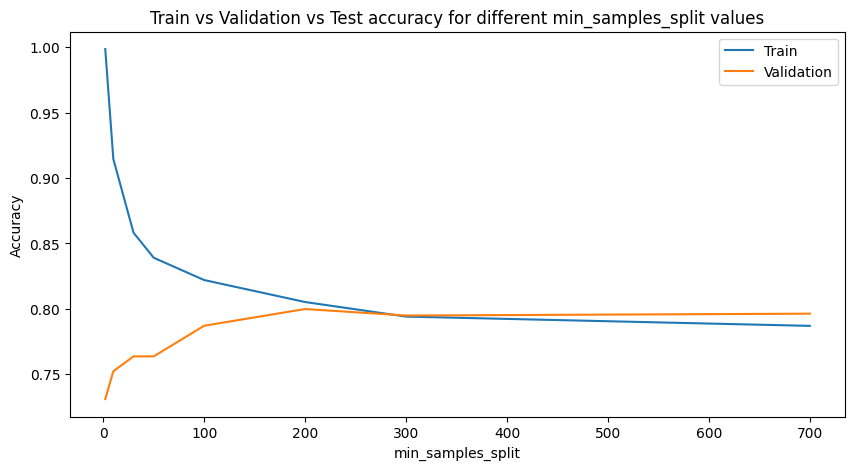

In [35]:
accuracy_scores_train = []
accuracy_scores_val = []
accuracy_scores_test = []
for min_sample in min_samples_split_list:
    model = DecisionTreeClassifier(min_samples_split=min_sample, random_state=42)
    model.fit(xtrain2, ytrain2)
    ytrain_pred = model.predict(xtrain2)
    yval_pred = model.predict(xval2) 
    ytest_pred = model.predict(xtest2)
    accuracy_train = accuracy_score(ytrain2, ytrain_pred)
    accuracy_val = accuracy_score(yval2, yval_pred)
    accuracy_test = accuracy_score(ytest2, ytest_pred)
    accuracy_scores_train.append(accuracy_train)
    accuracy_scores_val.append(accuracy_val)
    accuracy_scores_test.append(accuracy_test)
    print(f'min_samples_split: {min_sample}, Train Accuracy: {accuracy_train}, Validation Accuracy: {accuracy_val}, Test Accuracy: {accuracy_test}')

plt.figure(figsize=(10, 5))
plt.title('Train vs Validation vs Test accuracy for different min_samples_split values')
plt.xlabel('min_samples_split')
plt.ylabel('Accuracy')
plt.plot(min_samples_split_list, accuracy_scores_train, label='Train')
plt.plot(min_samples_split_list, accuracy_scores_val, label='Validation')
plt.legend()
plt.show()

Max Depth: 1, Train Score: 0.7349112426035503, CV Score: 0.7317246273953159
Max Depth: 2, Train Score: 0.7581065088757396, CV Score: 0.7686302342086586
Max Depth: 3, Train Score: 0.7869822485207101, CV Score: 0.7963094393186657
Max Depth: 4, Train Score: 0.7884023668639053, CV Score: 0.7906316536550745
Max Depth: 8, Train Score: 0.8369230769230769, CV Score: 0.7665010645848119
Max Depth: 16, Train Score: 0.9808284023668639, CV Score: 0.723207948899929
Max Depth: 32, Train Score: 0.9985798816568048, CV Score: 0.7310149041873669
Max Depth: 64, Train Score: 0.9985798816568048, CV Score: 0.7310149041873669
Max Depth: None, Train Score: 0.9985798816568048, CV Score: 0.7310149041873669


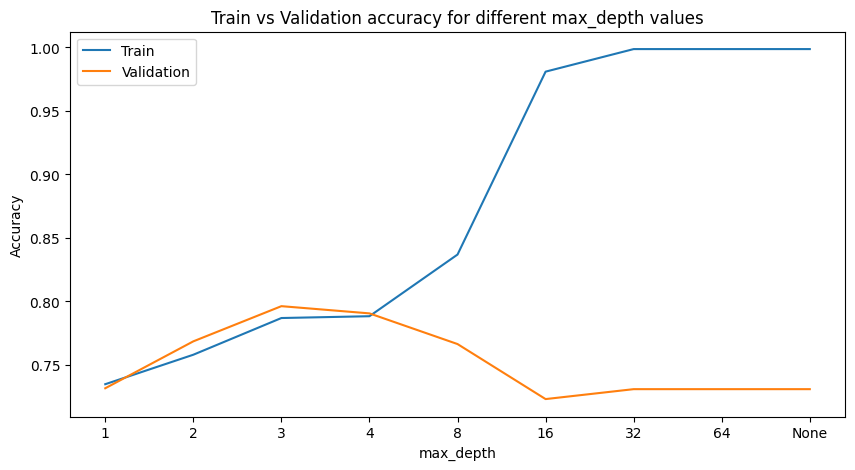

In [33]:
accuracy_scores_train = []
accuracy_scores_val = []
accuracy_scores_test = []
for max_depth in max_depth_list:
    model = DecisionTreeClassifier(max_depth=max_depth, random_state=42)
    model.fit(xtrain2, ytrain2)
    train_pred = model.predict(xtrain2)
    val_pred = model.predict(xval2)
    train_score = accuracy_score(train_pred, ytrain2)
    val_score = accuracy_score(val_pred, yval2)
    accuracy_scores_train.append(train_score)
    accuracy_scores_val.append(val_score)
    print(f'Max Depth: {max_depth}, Train Score: {train_score}, CV Score: {val_score}')

plt.figure(figsize=(10, 5))
plt.title('Train vs Validation accuracy for different max_depth values')
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.plot(accuracy_scores_train, label='Train')
plt.plot(accuracy_scores_val, label='Validation')
plt.xticks(ticks=range(len(max_depth_list)), labels=[str(d) for d in max_depth_list])
plt.legend()
plt.show()

In [ ]:
# Now use both max_depth and min_samples.

accuracy_scores_train = []
accuracy_scores_val = []
accuracy_scores_test = []
model = DecisionTreeClassifier(max_depth=3, min_samples_split=200, random_state=42)
model.fit(xtrain2, ytrain2)
train_pred = model.predict(xtrain2)
val_pred = model.predict(xval2)
test_pred = model.predict(xtest2)
train_score = accuracy_score(train_pred, ytrain2)
val_score = accuracy_score(val_pred, yval2)
test_score = accuracy_score(test_pred, ytest2)
accuracy_scores_train.append(train_score)
accuracy_scores_val.append(val_score)
print(f'Train Score: {train_score}, CV Score: {val_score}, Test Score: {test_score}')


Train Score: 0.7869822485207101, CV Score: 0.7963094393186657, Test Score: 0.794180269694819
